In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# nltk.download('wordnet')
# nltk.download('omw-1.4')
# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')  # For POS tagging
# Dir_github = '/work/desai-lab/xuanyang/Project/Semantic/analysis/FactorAnalysis/github'
Dir_github = '/work/desai-lab/xuanyang/Project/Semantic/dissemination/github/DiscoFMRI'
# Dir_github = r'Z:\study\phd\project\Semantics\FactorAnalysis\github'
repo = 'DiscoFMRI'
Dir_output = os.path.join(Dir_github,repo,'data','FactorAnalysis','output')


/home/xy6/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df_SCOPE_lemma = pd.read_csv(os.path.join(Dir_github,'data','SCOPE_lemma_var106.csv'))
df_SCOPE_lemma_text = pd.read_csv(os.path.join(Dir_github,'data','SCOPE_lemma_var106.csv'),usecols=["Word","Lemma"],keep_default_na=False, na_values=[])
df_SCOPE_lemma[['Word','Lemma']] = df_SCOPE_lemma_text[['Word','Lemma']]
print(f"{df_SCOPE_lemma['Lemma'].unique().shape[0]} lemmas")
print(f"{df_SCOPE_lemma['Word'].unique().shape[0]} Word")

df_var_113 = pd.read_csv(os.path.join(Dir_github,'data','List_113variables_sorted.csv'))
for var in ['Freq_','CD_']:
    df_var_113.loc[df_var_113['variable'].str.startswith(var),'variable'] = df_var_113.loc[df_var_113['variable'].str.startswith(var),'variable']+'_LemmaSum'

List_var_113 = list(df_var_113['variable'].values)

List_var_Freq_OrthPhon = ['Orth_N_Freq_L', 'Orth_N_Freq_G', 'Orth_N_Freq', 'Orth_N_Freq_L_Mean',
       'Orth_N_Freq_G_Mean', 'Phonographic_N_Freq', 'Phon_N_Freq']
List_var_106 = [x for x in List_var_113 if x not in List_var_Freq_OrthPhon]
List_vars = List_var_106

df_FA = df_SCOPE_lemma[List_vars]

df_FA.to_csv(os.path.join(Dir_output,'data_FactorAnalysis_var106.csv'),index=False)
df_FA

5905 lemmas
13850 Word


,Freq_HAL_LemmaSum,Freq_KF_LemmaSum,Freq_SUBTLEXUS_LemmaSum,Freq_SUBTLEXUS_Zipf_LemmaSum,Freq_SUBTLEXUK_LemmaSum,Freq_SUBTLEXUK_Zipf_LemmaSum,Freq_Blog_LemmaSum,Freq_Twitter_LemmaSum,Freq_News_LemmaSum,Freqtraj_TASA,...,Consistency_Token_FF_ON,Consistency_Type_FF_ON,Consistency_Token_FF_N,Consistency_Type_FF_N,Consistency_Token_FF,Consistency_Type_FF,ROOT1_PFMF,ROOT1_FamSize,ROOT1_Freq_HAL,NMorph
0,8.726687,1.845098,3.077368,1.369202,3.707911,1.403646,3.148294,2.518514,3.121560,1.059894,...,0.364154,0.382968,0.290996,0.290869,0.613306,0.613715,0.000000,2.0,10894.0,1.0
1,8.726687,1.845098,3.077368,1.369202,3.707911,1.403646,3.148294,2.518514,3.121560,0.935349,...,0.364154,0.382968,0.290996,0.290869,0.622736,0.620365,0.000000,2.0,10894.0,2.0
2,8.726687,1.845098,3.077368,1.369202,3.707911,1.403646,3.148294,2.518514,3.121560,0.251768,...,0.376663,0.385672,0.353800,0.349776,0.648016,0.649720,0.000000,2.0,10894.0,2.0
3,8.726687,1.845098,3.077368,1.369202,3.707911,1.403646,3.148294,2.518514,3.121560,1.059894,...,0.364154,0.382968,0.290996,0.290869,0.613306,0.613715,0.000000,2.0,10894.0,2.0
4,7.154003,1.146128,2.245513,0.537347,2.759668,0.455404,1.968483,1.230449,2.089905,0.660592,...,0.460542,0.455815,0.497420,0.500461,0.678082,0.673346,0.000000,2.0,2136.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13845,9.768454,1.397940,3.078819,1.370653,3.950851,1.646587,3.184975,3.100026,3.495128,0.642419,...,0.767880,0.800000,0.234083,0.236635,0.742672,0.765222,0.000000,3.0,21772.0,1.0
13846,9.768454,1.397940,3.078819,1.370653,3.950851,1.646587,3.184975,3.100026,3.495128,0.642419,...,0.767880,0.800000,0.234083,0.236635,0.800393,0.807327,0.000000,3.0,21772.0,2.0
13847,9.768454,1.397940,3.078819,1.370653,3.950851,1.646587,3.184975,3.100026,3.495128,1.412152,...,0.767880,0.800000,0.234083,0.236635,0.772996,0.787327,0.000000,3.0,21772.0,2.0
13848,9.768454,1.397940,3.078819,1.370653,3.950851,1.646587,3.184975,3.100026,3.495128,0.781722,...,0.634479,0.650000,0.366203,0.364322,0.725292,0.729285,0.000000,3.0,21772.0,2.0


# Factor Analysis

In [6]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import matplotlib.pyplot as plt
import seaborn as sns

df_FA = pd.read_csv(os.path.join(Dir_output,'data_FactorAnalysis_var106.csv'))
# Check the suitability of the data for factor analysis
bartlett_test, p_value = calculate_bartlett_sphericity(df_FA)
kmo_all, kmo_model = calculate_kmo(df_FA)
print(f"Bartlett's test p-value: {p_value}")
print(f"KMO: {kmo_model}")

fa = FactorAnalyzer(n_factors=df_FA.shape[1], rotation='oblimin', method='principal')
fa.fit(df_FA)


loadings = fa.loadings_
variance = fa.get_factor_variance()
ev,_ = fa.get_eigenvalues()


d:\Software\anaconda3\Lib\site-packages\factor_analyzer\factor_analyzer.py:109: RuntimeWarning: invalid value encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
d:\Software\anaconda3\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


Bartlett's test p-value: nan
KMO: 0.7153327204439178


In [10]:
Dir_output

'Z:\\study\\phd\\project\\Semantics\\FactorAnalysis\\github\\FactorAnalysis_fMRI\\scripts\\FactorAnalysis\\output'

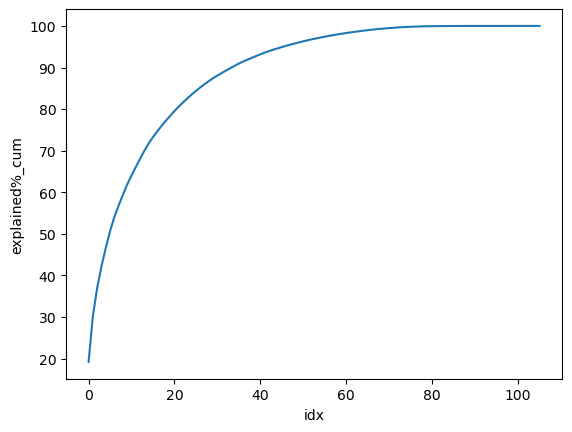

In [11]:
df_factors = pd.DataFrame({'ev':ev})
df_factors['explained%'] = df_factors['ev']/df_factors['ev'].sum()*100
df_factors['explained%_cum'] = df_factors['explained%'].cumsum()
df_factors['idx'] = df_factors.index
sns.lineplot(data = df_factors, x='idx',y='explained%_cum')
df_factors.to_csv(os.path.join(Dir_output,'df_factorloadings_eigenvalues.csv'),index=False)

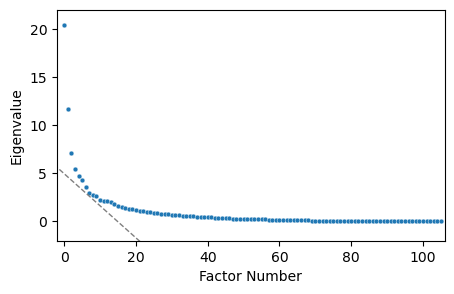

In [8]:
# Define the point (x1, y1) and slope a
x1, y1 = 7, df_factors.loc[7,'ev']
a = -1/3  # Change the slope as needed
x_line = np.linspace(df_factors['idx'].min()-20, df_factors['idx'].max(), 100)
y_line = a * (x_line - x1) + y1 -0.3

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3), dpi=100,sharex=True)

sns.scatterplot(data=df_factors, x='idx', y='ev', s=12, ax=ax)
ax.plot(x_line, y_line, label=f'Line with slope a={a}', color='gray',linestyle='--',linewidth=1)
# ax.scatter(x1, y1, color='red', label=f'Point ({x1}, {y1})',s=5) #, zorder=5
# ax.axhline(y=1, color='gray', linestyle=':')
ax.set(xlabel='Factor Number', ylabel='Eigenvalue',xlim=[-2,106],ylim=[-2,22])

# ccumulative
ax = axes[1]
sns.lineplot(data=df_factors, x='idx', y='explained%_cum', ax=ax,
             #marker='o',markersize=1
            )
ax.set(xlabel='Factor Number', ylabel='Cumulative Explained Variance',xlim=[-2,106])
ax.axhline(y=df_factors.loc[7,'explained%_cum'], color='gray', linestyle='--',linewidth=1)
# ax.legend()
plt.show()
fig.savefig(os.path.join(Dir_output,f'fig_screeplot_8factors_layout5.jpg'),bbox_inches="tight",dpi=300)

In [ ]:
# Define the point (x1, y1) and slope a
x1, y1 = 7, df_factors.loc[7,'ev']
a = -1/3  # Change the slope as needed
x_line = np.linspace(df_factors['idx'].min()-20, df_factors['idx'].max(), 100)
y_line = a * (x_line - x1) + y1 -0.3

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(5, 6), dpi=100,sharex=True)
ax = axes[0]
sns.scatterplot(data=df_factors, x='idx', y='ev', s=12, ax=ax)
ax.plot(x_line, y_line, label=f'Line with slope a={a}', color='gray',linestyle='--',linewidth=1)
# ax.scatter(x1, y1, color='red', label=f'Point ({x1}, {y1})',s=5) #, zorder=5
# ax.axhline(y=1, color='gray', linestyle=':')
ax.set(xlabel='Factor Number', ylabel='Eigenvalue',xlim=[-2,106],ylim=[-2,22])

plt.show()
fig.savefig(os.path.join(Dir_output,f'fig_screeplot_8factors_layout4.jpg'),bbox_inches="tight",dpi=300)

In [98]:
df_factors.loc[df_factors['ev']>=1]

,ev,explained%,explained%_cum,idx
0,20.361086,19.208571,19.208571,0
1,11.712264,11.049306,30.257877,1
2,7.160265,6.754967,37.012844,2
3,5.493114,5.182183,42.195027,3
4,4.693282,4.427625,46.622652,4
5,4.270618,4.028884,50.651536,5
6,3.619667,3.414780,54.066316,6
7,2.926405,2.760760,56.827076,7
8,2.731556,2.576939,59.404015,8
9,2.643043,2.493437,61.897452,9


In [6]:
df_factors.loc[df_factors['explained%_cum']<81]

,ev,explained%,explained%_cum,idx
0,20.361086,19.208571,19.208571,0
1,11.712264,11.049306,30.257877,1
2,7.160265,6.754967,37.012844,2
3,5.493114,5.182183,42.195027,3
4,4.693282,4.427625,46.622652,4
5,4.270618,4.028884,50.651536,5
6,3.619667,3.414780,54.066316,6
7,2.926405,2.760760,56.827076,7
8,2.731556,2.576939,59.404015,8
9,2.643043,2.493437,61.897452,9


# Experiment on different number of factors

In [121]:
def runFactorAnalysis(df_FA,N_factors,score_cutoff,List_vars,Dir_output):
    fa = FactorAnalyzer(rotation = 'oblimin',method='principal',n_factors=N_factors)
    fa.fit(df_FA)
    ev,_ = fa.get_eigenvalues()
    fig, axes = plt.subplots(nrows=1,ncols=1,figsize=(8,4))
    sns.scatterplot(x=range(1,df_FA.shape[1]+1),y=ev,ax=axes)
    loadings = fa.loadings_

    df_loadings = pd.DataFrame(loadings, index=list(List_vars), columns=[f'Factor {i+1}' for i in range(fa.n_factors)])

    df_loadings_new = df_loadings.copy()
    for iFA in df_loadings_new.columns:
        df_loadings_new.loc[df_loadings_new[iFA].abs()<=score_cutoff,iFA] = np.nan

    df_loadings_new = df_loadings_new.sort_values(df_loadings_new.columns.to_list(),ascending=False)
    df_loadings = df_loadings.loc[df_loadings_new.index.to_list()].copy()
    

    fig = plt.figure(figsize=(12, 40))
    sns.heatmap(df_loadings_new,  cmap='coolwarm') #annot=True,
    plt.title('Factor Loadings')
    plt.show()
    fig.savefig(os.path.join(Dir_output,f'fig_EFA_{N_factors}factors.jpg'), bbox_inches = 'tight')
    
    factor_scores = fa.transform(df_FA)
    df_factor_scores = pd.DataFrame(factor_scores, columns=[f'F{i+1}_n{fa.n_factors}' for i in range(fa.n_factors)])
    df_factor_scores.to_csv(os.path.join(Dir_output,f'scores_FA_n{N_factors}.csv'),index=False)
    
    print(f"{N_factors} factors explained {round(ev[0:N_factors].sum()/ev.sum()*100,2)}% of variance.")
    return(df_loadings,df_loadings_new,df_factor_scores)

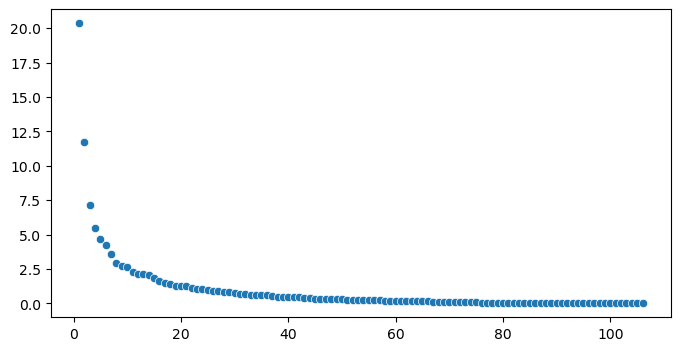

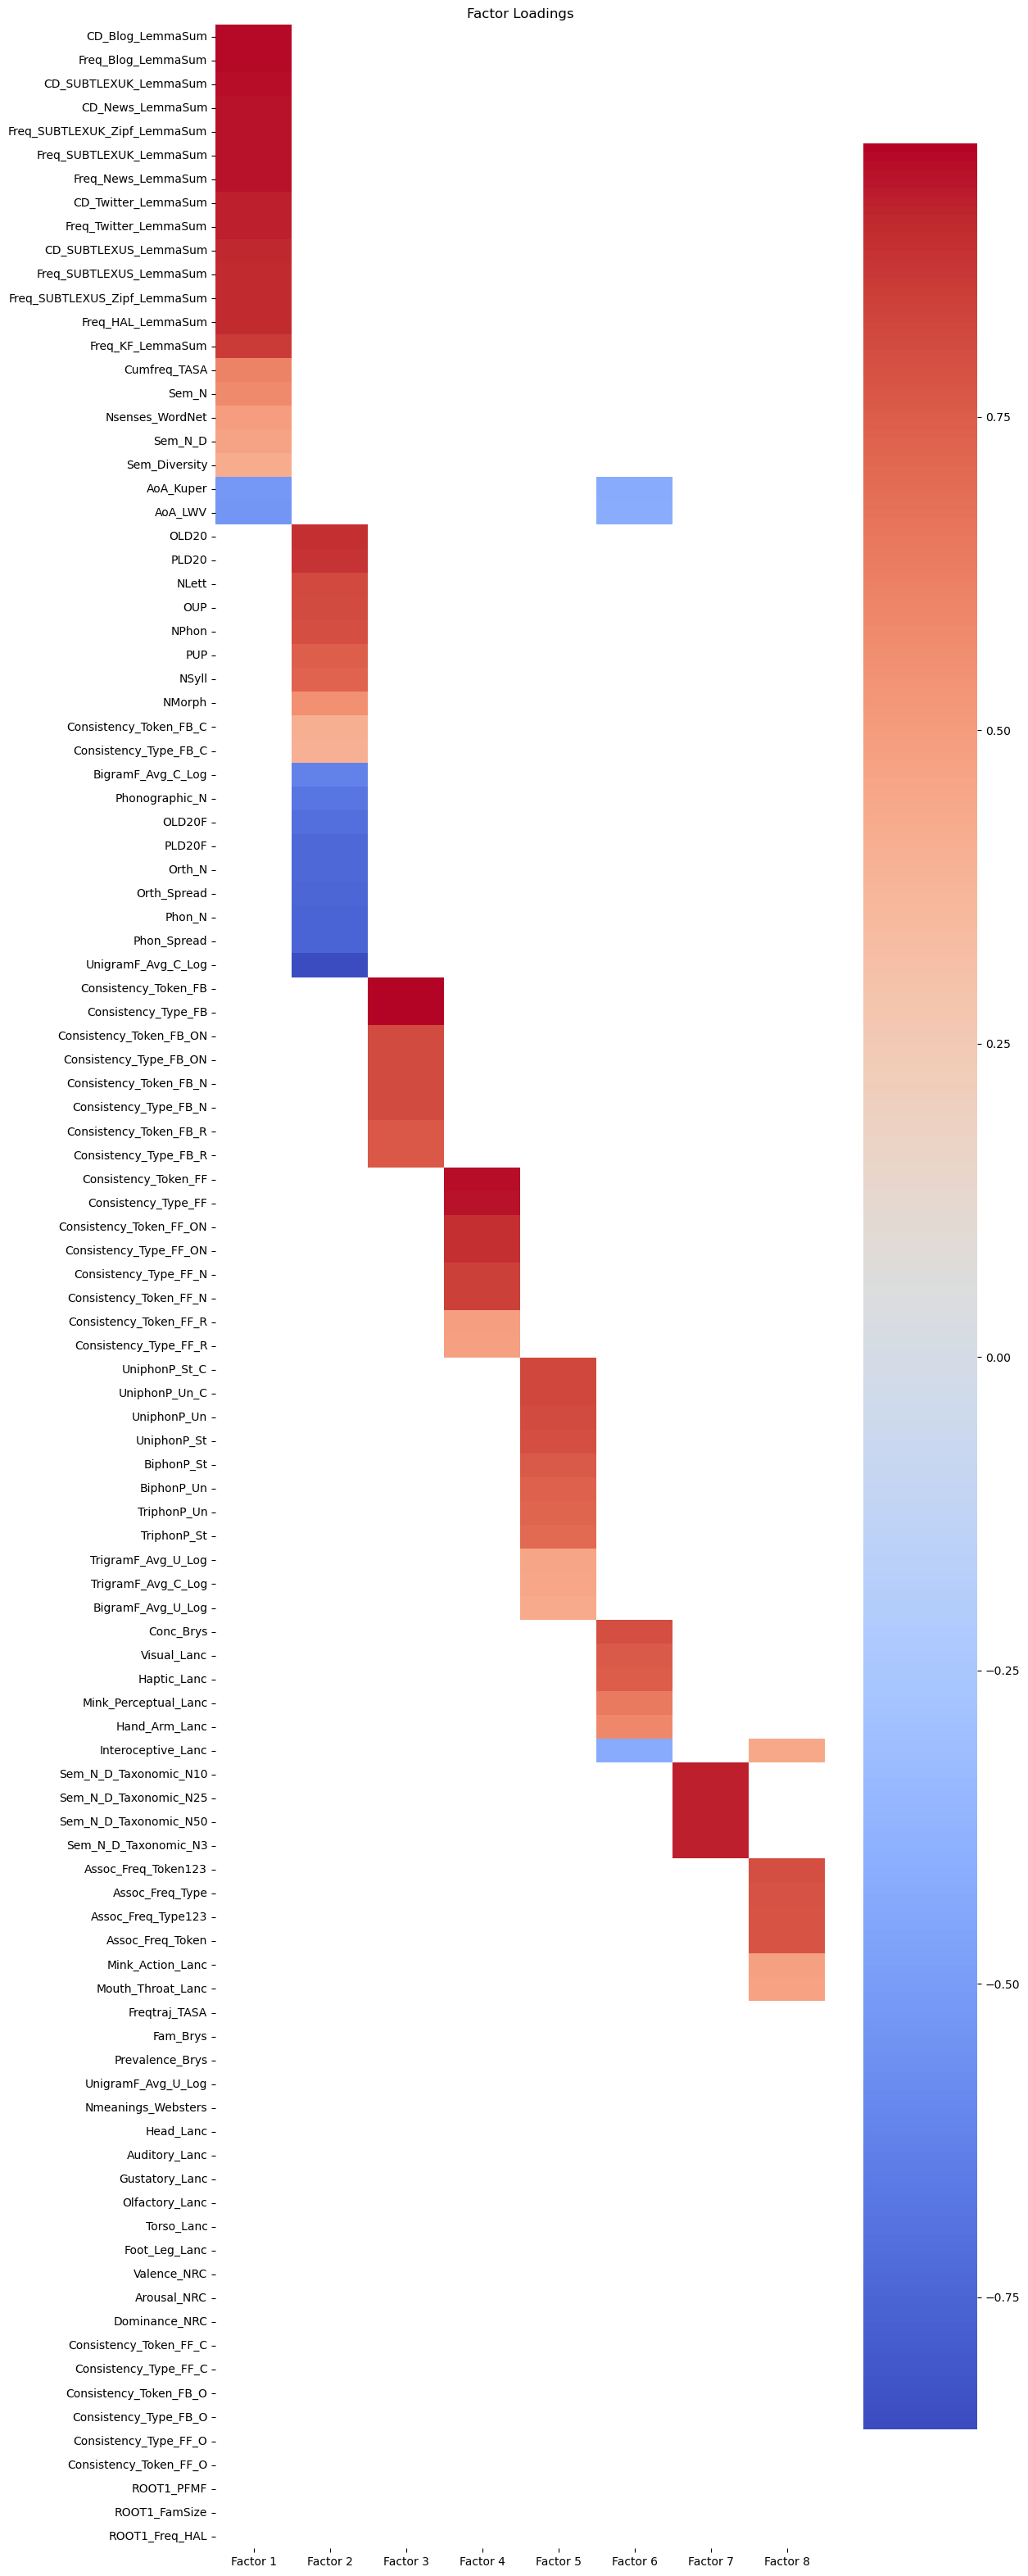

8 factors explained 56.83% of variance.


In [122]:
Dir_output = os.path.join(Dir_github,project,'scripts','FactorAnalysis','output')
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
score_cutoff = 0.4
N_factors = 8
[df_loadings,df_loadings_new,df_factor_scores] = runFactorAnalysis(df_FA,N_factors,score_cutoff,List_vars,Dir_output)
df_output = pd.concat([df_SCOPE_lemma,df_factor_scores],axis=1)
df_output.to_csv(os.path.join(Dir_output,f'data_FA_n{N_factors}.csv'),index=False)

# export the loading table for the paper Table 2
df = df_loadings.round(3).reset_index()
df.to_csv(os.path.join(Dir_output,f'FA_n{N_factors}_loadings_full.csv'),index=False)

df = df_loadings_new.round(3).reset_index()
df.to_csv(os.path.join(Dir_output,f'FA_n{N_factors}_loadings.csv'),index=False)

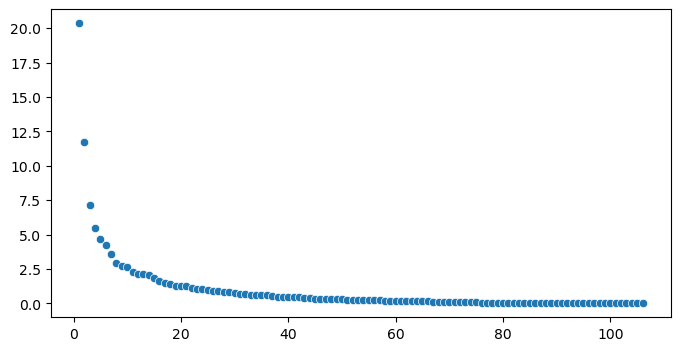

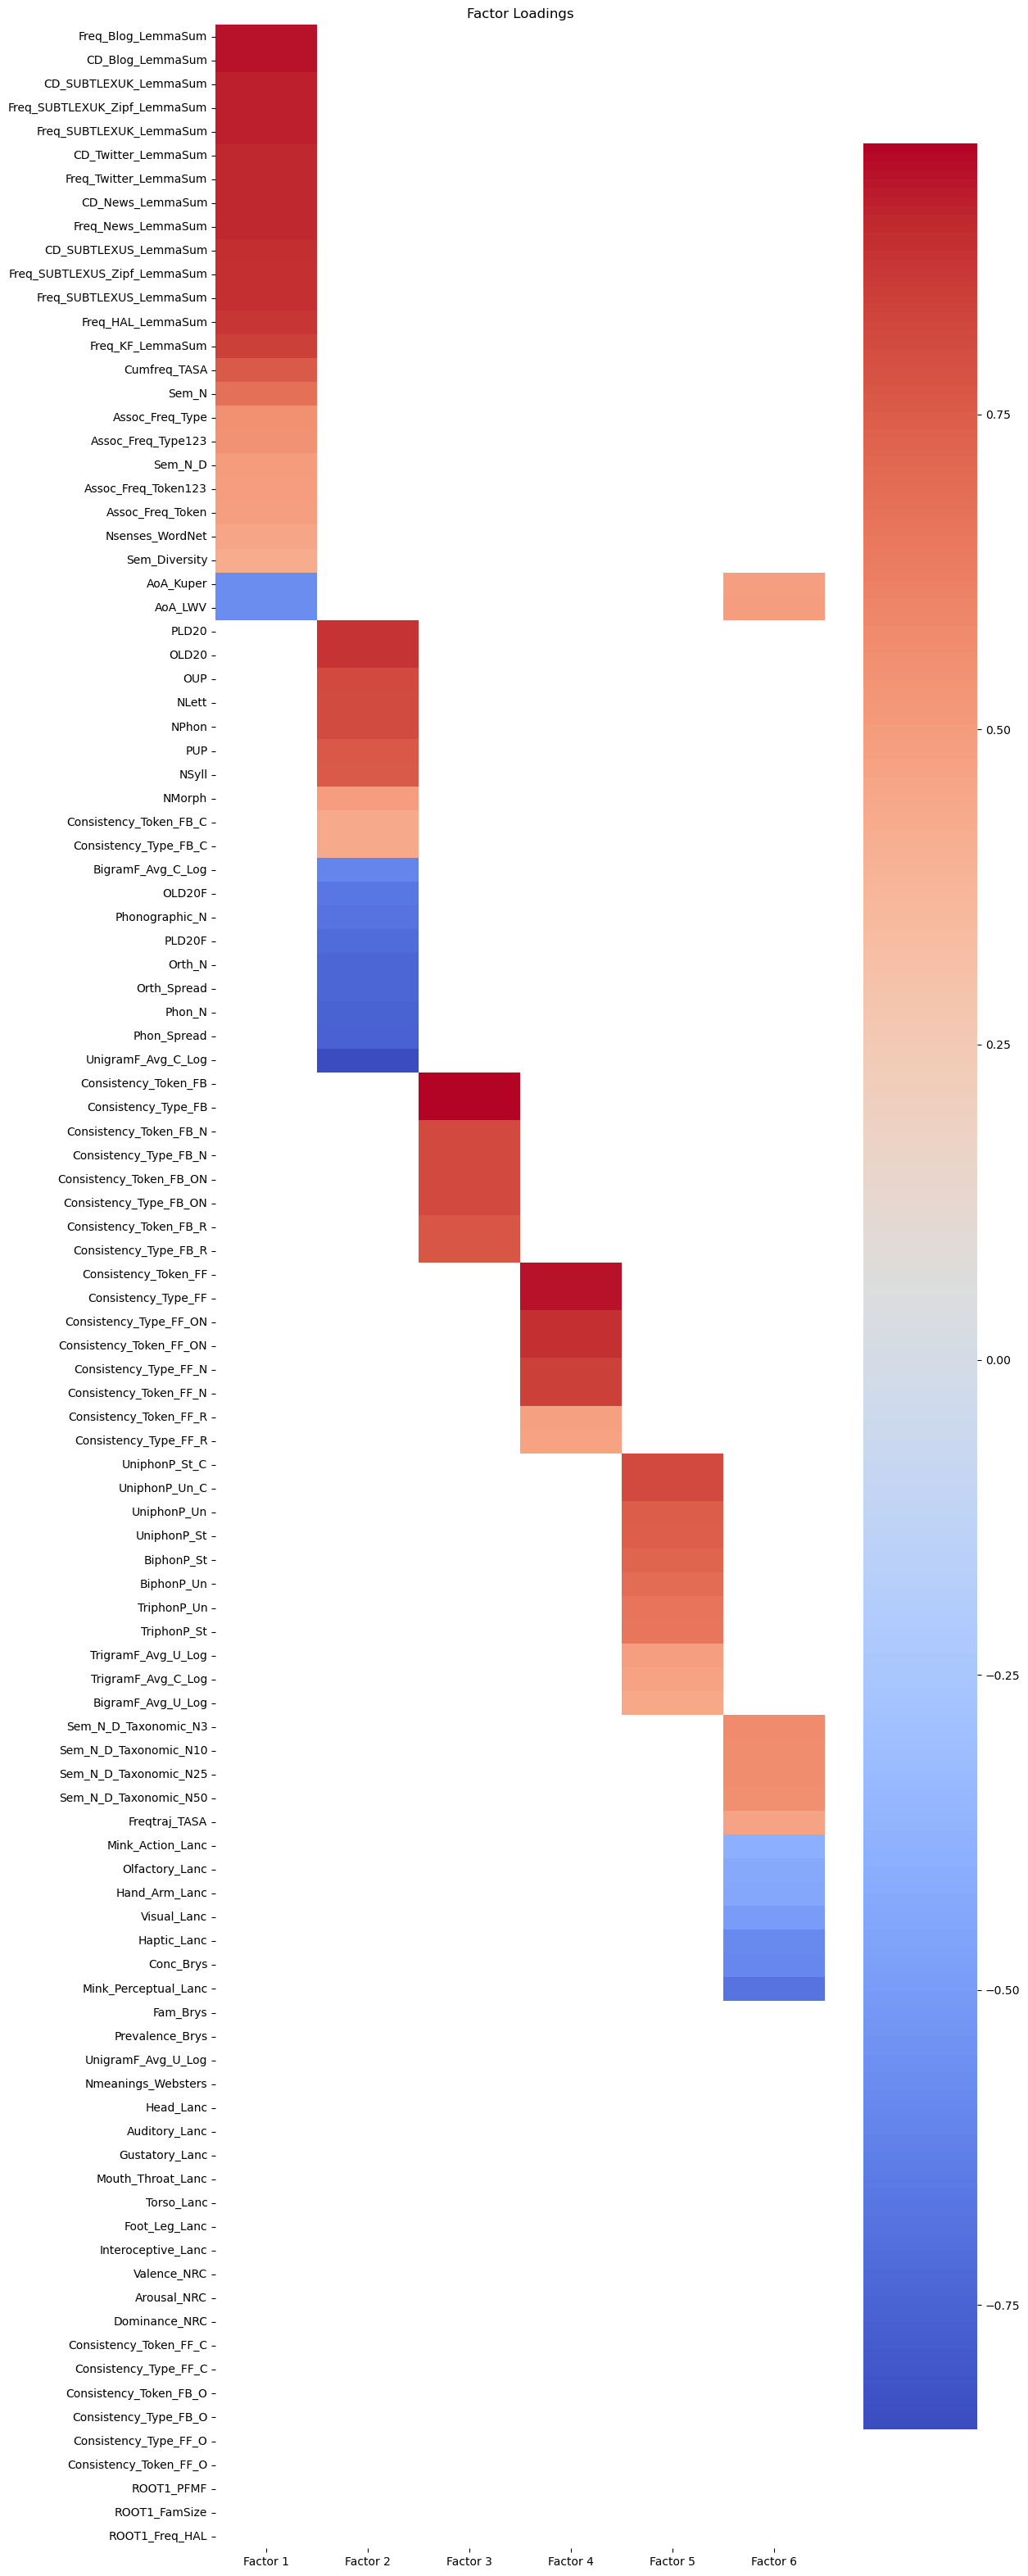

6 factors explained 50.65% of variance.


In [8]:
Dir_output = os.path.join(Dir_github,project,'scripts','FactorAnalysis','output')
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
score_cutoff = 0.4
N_factors = 6
[df_loadings,df_loadings_new,df_factor_scores] = runFactorAnalysis(df_FA,N_factors,score_cutoff,List_vars,Dir_output)
df_output = pd.concat([df_SCOPE_lemma,df_factor_scores],axis=1)
df_output.to_csv(os.path.join(Dir_output,f'data_FA_n{N_factors}.csv'),index=False)

# export the loading table for the paper Table 1
df = df_loadings_new.reset_index()
df.to_csv(os.path.join(Dir_output,f'FA_n{N_factors}_loadings.csv'),index=False)

/work/apps/python3/anaconda/2023.9/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/work/apps/python3/anaconda/2023.9/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


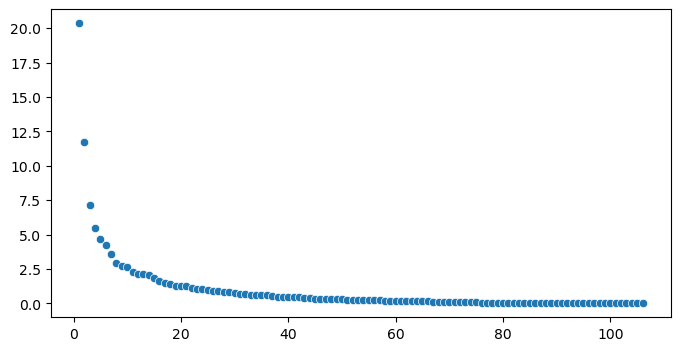

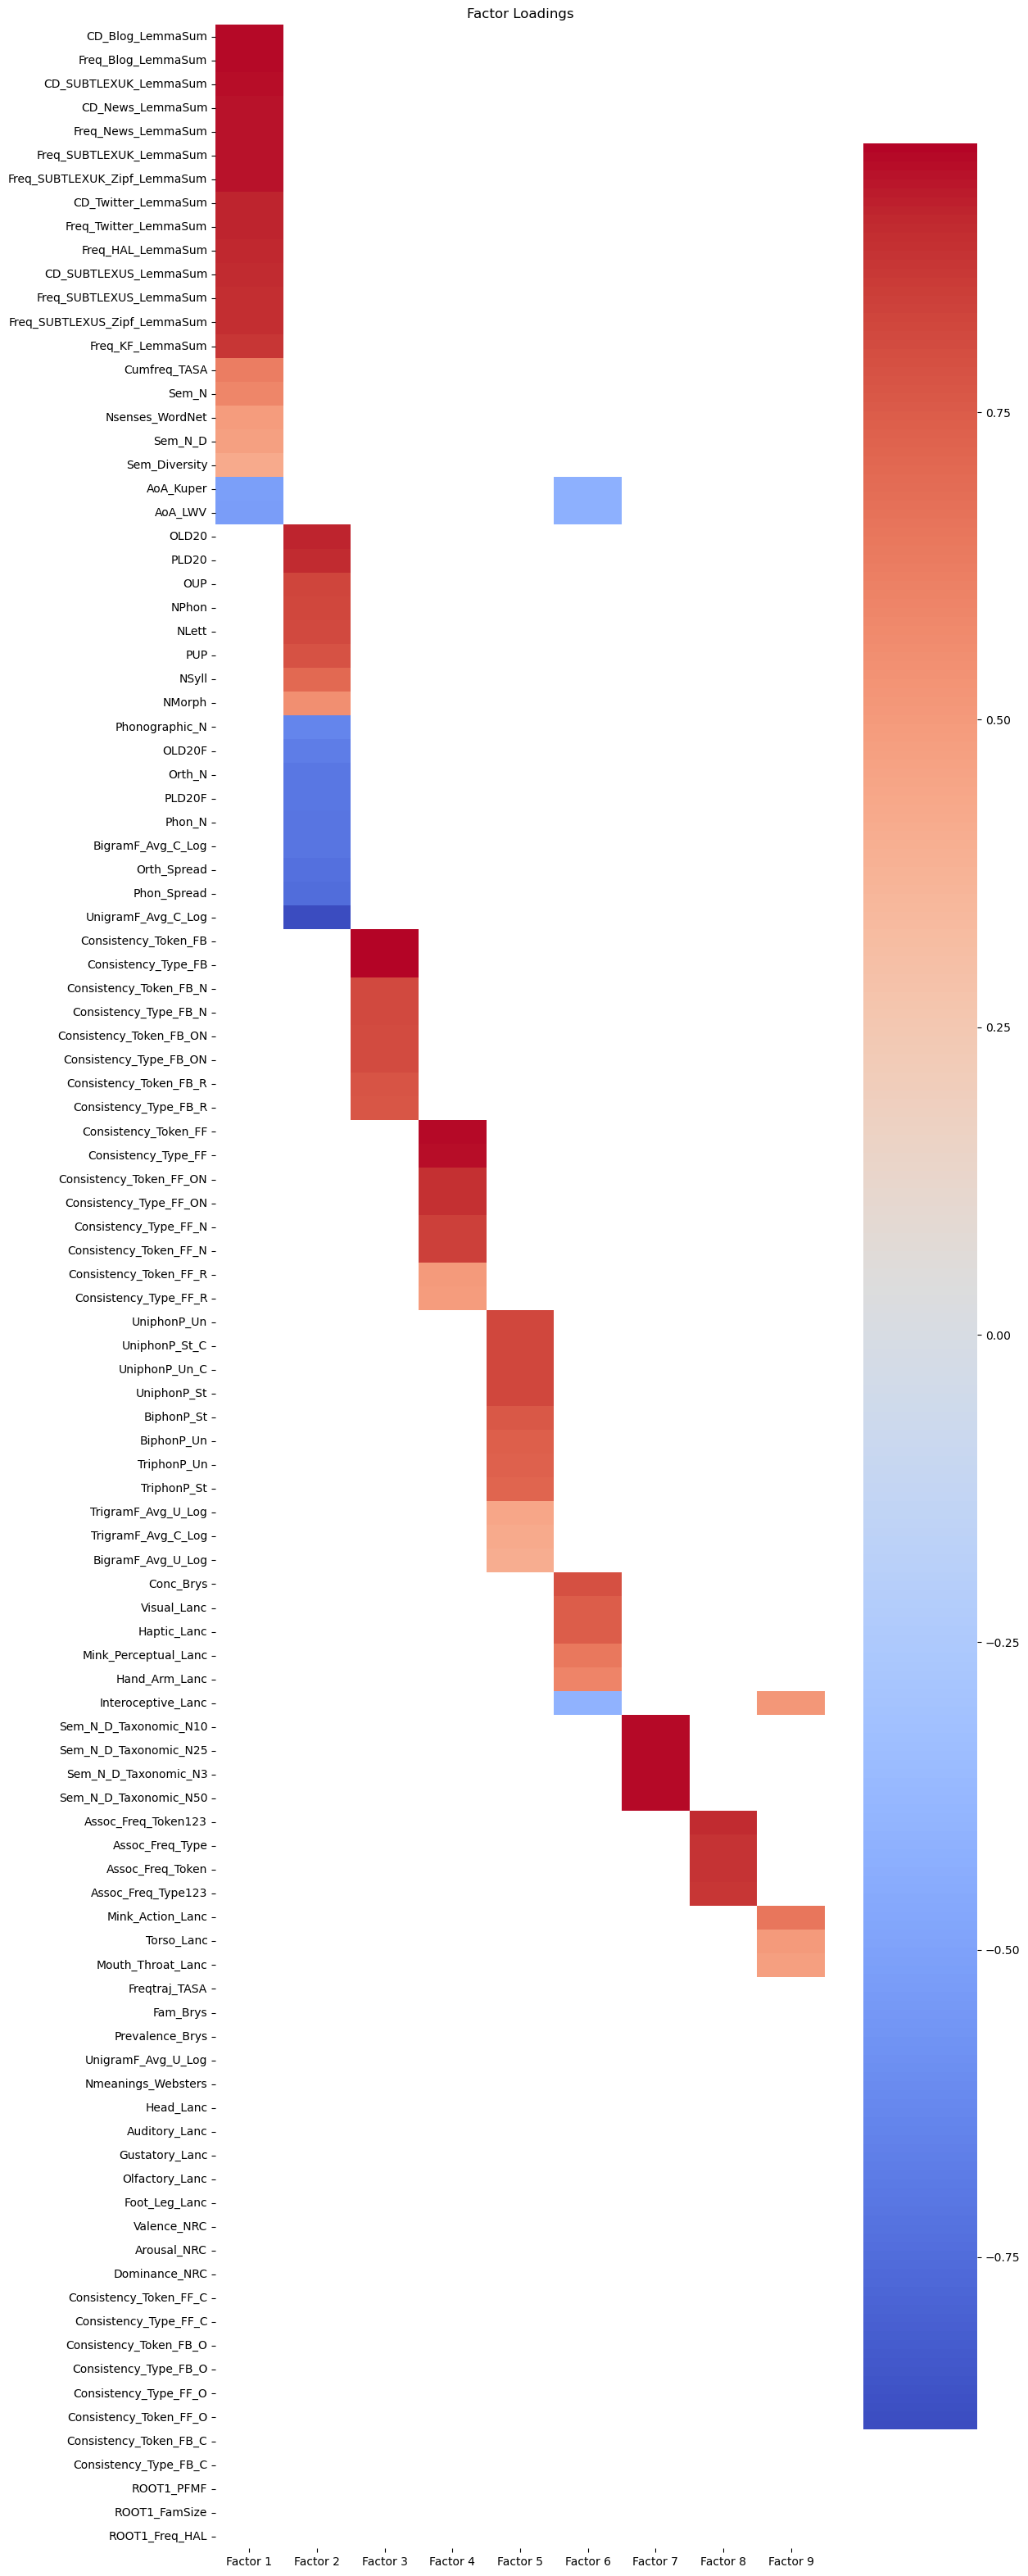

9 factors explained 59.4% of variance.


In [7]:
Dir_output = os.path.join(Dir_github,project,'scripts','FactorAnalysis','output')
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
score_cutoff = 0.4
N_factors = 9
[df_loadings,df_loadings_new,df_factor_scores] = runFactorAnalysis(df_FA,N_factors,score_cutoff,List_vars,Dir_output)
df_output = pd.concat([df_SCOPE_lemma,df_factor_scores],axis=1)
df_output.to_csv(os.path.join(Dir_output,f'data_FA_n{N_factors}.csv'),index=False)

# export the loading table for the paper Table 1
df = df_loadings_new.reset_index()
df.to_csv(os.path.join(Dir_output,f'FA_n{N_factors}_loadings.csv'),index=False)

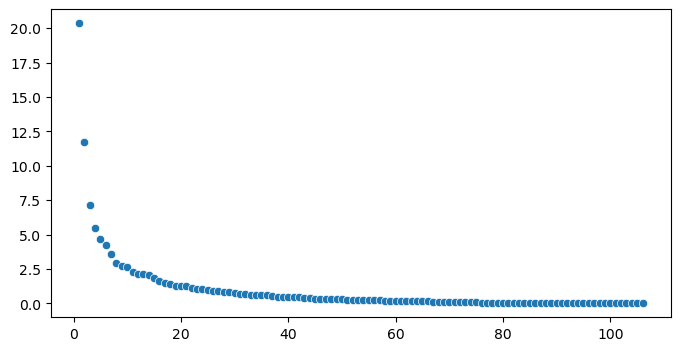

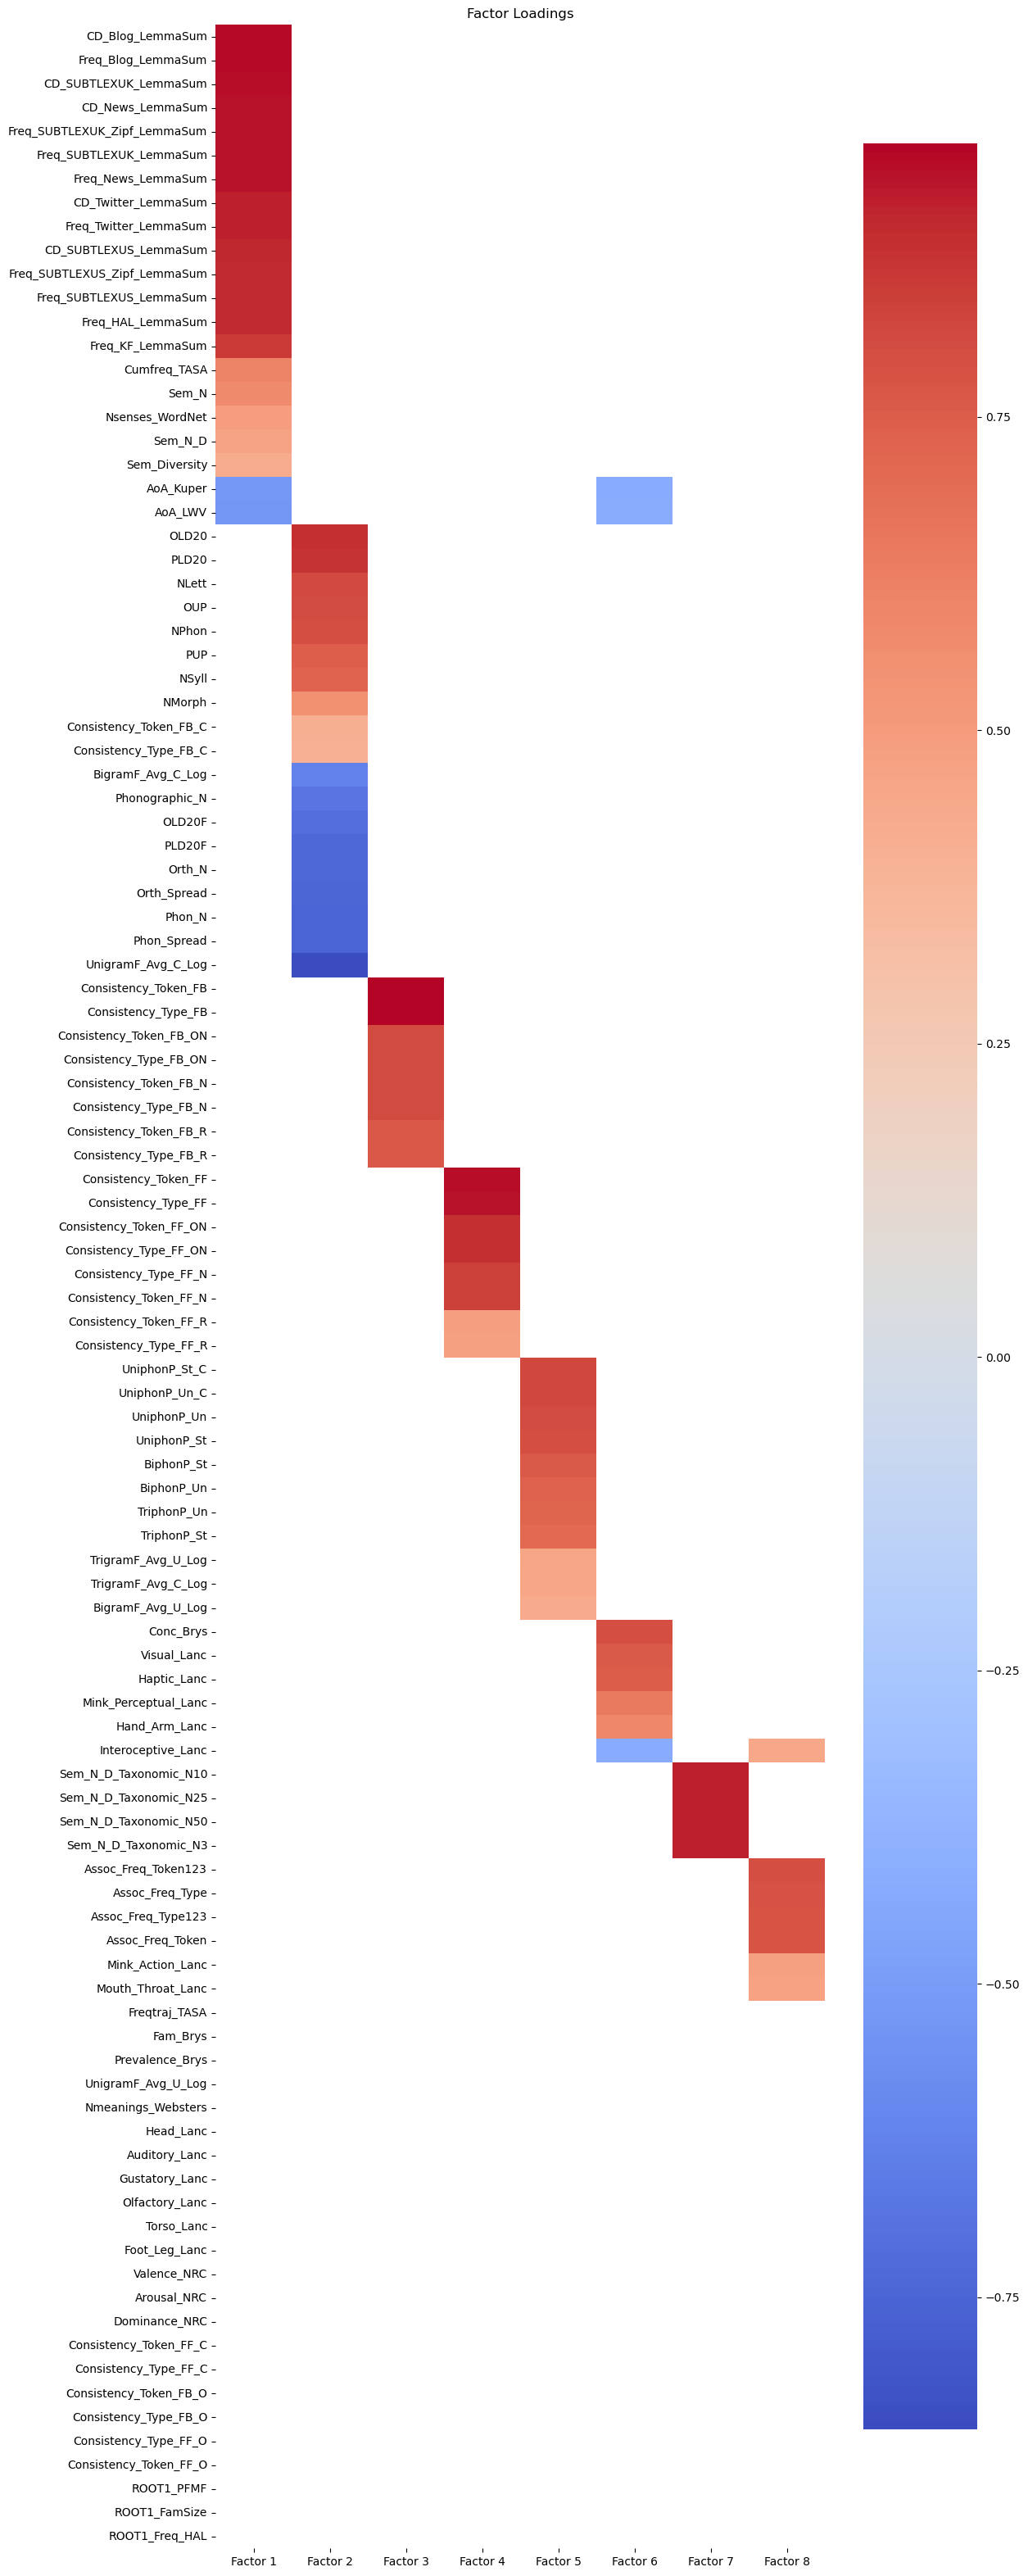

8 factors explained 56.83% of variance.


In [9]:
Dir_output = os.path.join(Dir_github,project,'scripts','FactorAnalysis','output')
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
score_cutoff = 0.4
N_factors = 8
[df_loadings,df_loadings_new,df_factor_scores] = runFactorAnalysis(df_FA,N_factors,score_cutoff,List_vars,Dir_output)
df_output = pd.concat([df_SCOPE_lemma,df_factor_scores],axis=1)
df_output.to_csv(os.path.join(Dir_output,f'data_FA_n{N_factors}.csv'),index=False)

# export the loading table for the paper Table 1
df = df_loadings_new.reset_index()
df.to_csv(os.path.join(Dir_output,f'FA_n{N_factors}_loadings.csv'),index=False)

In [9]:
# export the top N words for Table 2
df_factor_scores['word'] = df_SCOPE_lemma['Word']
df_factor_scores['lemma'] = df_SCOPE_lemma['Lemma']
df_factor_scores['word/lemma'] = df_factor_scores['word']+'/'+df_factor_scores['lemma']
table_words = []
N_words = 40
for i in range(1,N_factors+1):
#     print(f'FA{i}-positive:')
    List_pos = df_factor_scores.sort_values([f"F{i}_n{N_factors}"],ascending = False).reset_index(drop=True).loc[0:N_words-1,'word/lemma'].values
#     print(List_pos)
    table_words.append(pd.DataFrame({'FA':i,'idx':list(range(N_words)),'word':List_pos,'label':'pos'}))
    
#     print(f'FA{i}-negative:')
    List_neg = df_factor_scores.sort_values([f"F{i}_n{N_factors}"],ascending = True).reset_index(drop=True).loc[0:N_words-1,'word/lemma'].values
#     print(List_neg)
    table_words.append(pd.DataFrame({'FA':i,'idx':list(range(N_words)),'word':List_neg,'label':'neg'}))
table_words = pd.concat(table_words,ignore_index=True)

for label in ['pos','neg']:
    df = table_words.loc[table_words['label']==label].pivot(index='idx', columns='FA', values='word')
    df.to_csv(os.path.join(Dir_output,f"FAn{N_factors}_top{N_words}_{label}.csv"),index=False)


In [1]:
import pandas as pd
df = pd.read_csv('/work/desai-lab/xuanyang/Project/Semantic/analysis/FactorAnalysis/github/FactorAnalysis_fMRI/scripts/FactorAnalysis/output/FAn9_top40_pos.csv')
df

,1,2,3,4,5,6,7,8,9
0,are/be,bibliographies/bibliography,man/man,squealed/squeal,continent/continent,puppy/puppy,operate/operate,food/food,sexing/sex
1,was/be,manufacturers/manufacturer,hands/hand,liars/liar,contention/contention,soaps/soap,compared/compare,money/money,excited/excite
2,being/be,grandchildren/grandchild,bagging/bag,liar/liar,contentions/contention,soap/soap,occur/occur,monies/money,itching/itch
3,were/be,relationships/relationship,stands/stand,sleeps/sleep,continents/continent,puppies/puppy,compare/compare,water/water,itches/itch
4,been/be,entrepreneurs/entrepreneur,slashed/slash,swum/swim,distant/distant,pumpkin/pumpkin,feature/feature,car/car,hungered/hunger
5,have/have,championships/championship,smashed/smash,prior/prior,destination/destination,sofas/sofa,give/give,work/work,exhaustion/exhaustion
6,having/have,agricultural/agricultural,stabbing/stab,snug/snug,contraction/contraction,biscuits/biscuit,operates/operate,love/love,hungers/hunger
7,does/do,dictatorships/dictatorship,bands/band,boils/boil,contaminated/contaminate,swords/sword,form/form,bad/bad,scaring/scare
8,had/have,enthusiastic/enthusiastic,tramping/tramp,quaint/quaint,scenting/scent,sword/sword,comparing/compare,bads/bad,tensing/tense
9,has/have,manufacturer/manufacturer,banked/bank,bleeds/bleed,continuation/continuation,lotions/lotion,regard/regard,red/red,hungering/hunger


In [10]:
df = table_words.loc[table_words['label']=='neg'].pivot(index='idx', columns='FA', values='word')
df

FA,1,2,3,4,5,6,7,8
idx,,,,,,,,
0,homogeneous/homogeneous,may/may,twos/two,cough/cough,ooze/ooze,witting/wit,coughing/cough,modes/mode
1,heredity/heredity,mane/mane,knew/know,one/one,joy/joy,divining/divine,kidding/kid,enzymes/enzyme
2,bluish/bluish,hay/hay,one/one,hour/hour,vow/vow,theoretical/theoretical,sneezing/sneeze,wholesale/wholesale
3,weariness/weariness,cane/cane,rhyme/rhyme,coughs/cough,oak/oak,was/be,laughs/laugh,enzyme/enzyme
4,linoleum/linoleum,say/say,suite/suite,was/be,egg/egg,eminent/eminent,licking/lick,centuries/century
5,warlike/warlike,mare/mare,heir/heir,fuse/fuse,jaw/jaw,wits/wit,stinking/stink,municipal/municipal
6,consequent/consequent,tore/tear,heirs/heir,coup/coup,ego/ego,were/be,cries/cry,transferred/transfer
7,fibrous/fibrous,line/line,ceased/cease,trough/trough,odd/odd,storied/story,giggling/giggle,predecessors/predecessor
8,drawbridge/drawbridge,pay/pay,suites/suite,regime/regime,eyeball/eyeball,imperative/imperative,snoring/snore,parallels/parallel


# Correlation with behavioral responses

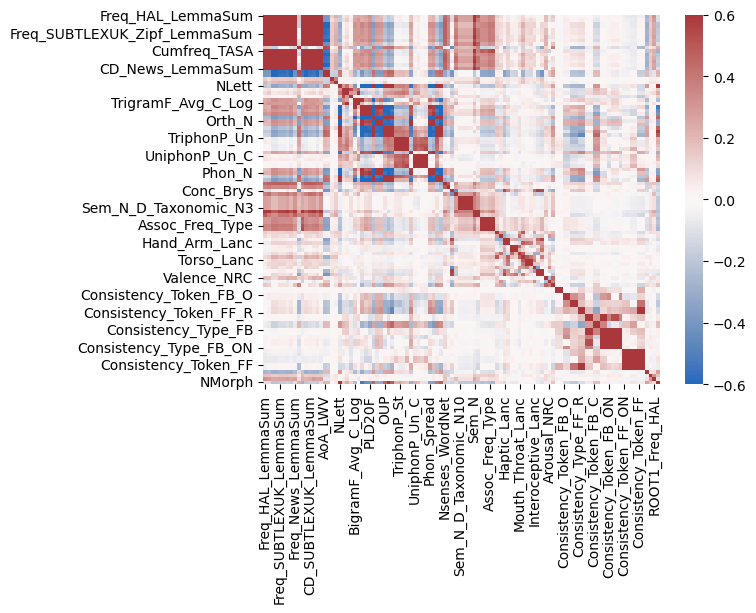

In [21]:
df_corr = df_FA[List_vars].corr()
ax = sns.heatmap(df_corr,cmap='vlag',vmin=-0.6,vmax=0.6) 
ax.set(xlabel='',ylabel='')
fig = ax.get_figure()
fig.savefig(os.path.join(Dir_output,f'fig_corr_106vars.jpg'),bbox_inches="tight",dpi=300)

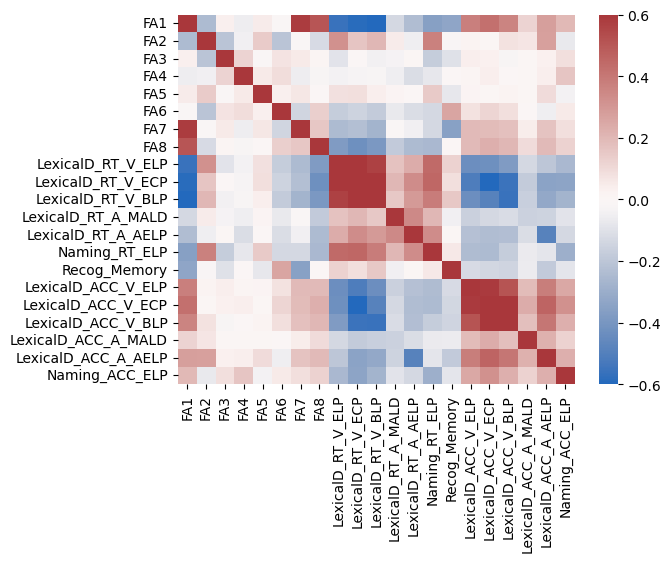

In [11]:
df_SCOPE_raw = pd.read_csv(os.path.join(Dir_github,'data',f"SCOPE_word.csv"))
df = pd.read_csv(os.path.join(Dir_github,'data',f"SCOPE_word.csv"), usecols=["Word"], keep_default_na=False, na_values=[],encoding="latin-1")
df_SCOPE_raw['Word'] = df['Word'] 
df_SCOPE_raw = df_SCOPE_raw.loc[~df_SCOPE_raw['Word'].duplicated()].reset_index() # the word "used" is duplicated

df1 = df_SCOPE_lemma.set_index('Word')

df2 = df_SCOPE_raw.set_index('Word')
List_var_RT = [x for x in df_SCOPE_raw.columns if '_RT_' in x and '_z' in x and 'Calgary' not in x]
List_var_ACC = [x for x in df_SCOPE_raw.columns if '_ACC_' in x and 'Calgary' not in x]
List_var_Y = List_var_RT+['Recog_Memory']+List_var_ACC

df1[List_var_Y] = df2.loc[df1.index,List_var_Y]

List_FA = [x for x in df_factor_scores.columns if f'_n{N_factors}' in x]
df1[List_FA] = df_factor_scores.set_index('word')[List_FA]
df1 = df1.dropna()[List_FA+List_var_Y]
df1.columns = [[f"FA{x}" for x in range(1,N_factors+1)]+[x.replace('_z','') for x in List_var_Y]]
df_corr = df1.corr()
ax = sns.heatmap(df_corr,cmap='vlag',vmin=-0.6,vmax=0.6) 
ax.set(xlabel='',ylabel='')
fig = ax.get_figure()
fig.savefig(os.path.join(Dir_output,f'fig_corr_responsen_{N_factors}.jpg'),bbox_inches="tight",dpi=300)

In [12]:
df_corr

,FA1,FA2,FA3,FA4,FA5,FA6,FA7,FA8,LexicalD_RT_V_ELP,LexicalD_RT_V_ECP,...,LexicalD_RT_A_MALD,LexicalD_RT_A_AELP,Naming_RT_ELP,Recog_Memory,LexicalD_ACC_V_ELP,LexicalD_ACC_V_ECP,LexicalD_ACC_V_BLP,LexicalD_ACC_A_MALD,LexicalD_ACC_A_AELP,Naming_ACC_ELP
FA1,1.000000,-0.247112,0.034560,-0.056373,0.051436,-0.010560,0.582102,0.508342,-0.559119,-0.588142,...,-0.135934,-0.234898,-0.360831,-0.337370,0.375192,0.423574,0.362027,0.120526,0.278964,0.198614
FA2,-0.247112,1.000000,-0.209613,-0.049213,0.143453,-0.209954,-0.017340,-0.124882,0.319171,0.161349,...,0.048842,-0.055619,0.372091,-0.019312,0.022325,0.000397,0.077139,0.070219,0.272545,-0.072850
FA3,0.034560,-0.209613,1.000000,0.121680,-0.011495,0.071028,0.051639,0.012032,-0.091152,-0.001497,...,-0.035088,0.008155,-0.174368,-0.101946,0.038822,0.030950,-0.024353,0.008745,0.029294,0.086696
FA4,-0.056373,-0.049213,0.121680,1.000000,0.052436,0.092026,-0.057653,-0.027413,-0.041919,-0.031204,...,-0.055499,-0.114625,-0.079686,-0.002227,0.013577,0.039563,-0.007739,0.004639,0.041406,0.162676
FA5,0.051436,0.143453,-0.011495,0.052436,1.000000,0.033881,0.061139,-0.008363,0.081930,0.086573,...,0.015241,-0.005837,0.147301,-0.079190,0.017910,0.009023,0.020876,0.006119,0.094375,-0.038886
FA6,-0.010560,-0.209954,0.071028,0.092026,0.033881,1.000000,-0.141802,0.131848,-0.177281,-0.153714,...,-0.070780,-0.115758,-0.133719,0.259512,0.078729,0.113104,0.085431,-0.007954,-0.055747,0.053583
FA7,0.582102,-0.017340,0.051639,-0.057653,0.061139,-0.141802,1.000000,0.155200,-0.247769,-0.225475,...,-0.017715,-0.048210,-0.135517,-0.355287,0.196332,0.190621,0.174084,0.043853,0.165312,0.086037
FA8,0.508342,-0.124882,0.012032,-0.027413,-0.008363,0.131848,0.155200,1.000000,-0.377737,-0.427223,...,-0.185042,-0.247291,-0.254815,-0.001278,0.196385,0.225520,0.204710,0.098388,0.196375,0.126511
LexicalD_RT_V_ELP,-0.559119,0.319171,-0.091152,-0.041919,0.081930,-0.177281,-0.247769,-0.377737,1.000000,0.610142,...,0.171557,0.235179,0.440912,0.123805,-0.435338,-0.430243,-0.378892,-0.131885,-0.199517,-0.253303
LexicalD_RT_V_ECP,-0.588142,0.161349,-0.001497,-0.031204,0.086573,-0.153714,-0.225475,-0.427223,0.610142,1.000000,...,0.205941,0.337497,0.450758,0.085790,-0.512113,-0.645897,-0.554794,-0.178876,-0.344085,-0.339483
